# Batch review LangGraph visualization

This notebook imports the graph from `src.batch_review_graph` and renders its current structure.

In [2]:
import sys
from pathlib import Path

# Works when the notebook is opened from the src directory or repository root.
here = Path.cwd().resolve()
repo = here.parent if here.name == 'src' else here
sys.path.insert(0, str(repo))

from IPython.display import Image, display
from src.batch_review_graph import build_graph

app = build_graph()
print('Graph imported successfully from:', repo)

Graph imported successfully from: /Users/dc/geha/clean_pdf_langgraph


In [3]:
# Print the graph definition as Mermaid text.
mermaid = app.get_graph().draw_mermaid()
print(mermaid)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__(<p>__start__</p>)
	docling_extract(docling_extract)
	build_combined_html(build_combined_html)
	render_pdf_pages(render_pdf_pages)
	cycle_html_tables(cycle_html_tables)
	vision_compare(vision_compare)
	corrected_slideshow(corrected_slideshow)
	vision_declined(vision_declined)
	write_extractor_reports(write_extractor_reports)
	__end__(<p>__end__</p>)
	__start__ --> docling_extract;
	build_combined_html --> render_pdf_pages;
	corrected_slideshow --> write_extractor_reports;
	cycle_html_tables --> vision_compare;
	docling_extract --> build_combined_html;
	render_pdf_pages --> cycle_html_tables;
	vision_compare --> corrected_slideshow;
	write_extractor_reports --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



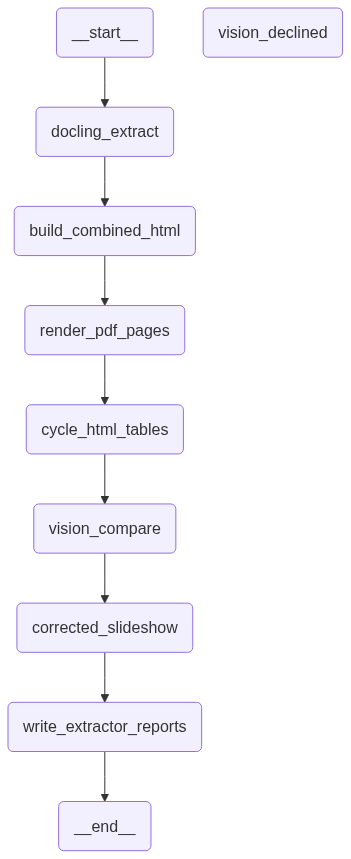

Saved: /Users/dc/geha/clean_pdf_langgraph/src/batch_review_graph.png


In [4]:
# Render the graph as a PNG and save it beside this notebook.
png_bytes = app.get_graph().draw_mermaid_png()
png_path = repo / 'src' / 'batch_review_graph.png'
png_path.write_bytes(png_bytes)
display(Image(png_bytes))
print('Saved:', png_path)

In [5]:
7# Optional: inspect node names and directed edges.
graph_view = app.get_graph()
print('Nodes:', sorted(graph_view.nodes))
print('Edges:')
for edge in graph_view.edges:
    print(f'  {edge.source} -> {edge.target}')

Nodes: ['__end__', '__start__', 'build_combined_html', 'corrected_slideshow', 'cycle_html_tables', 'docling_extract', 'render_pdf_pages', 'vision_compare', 'vision_declined', 'write_extractor_reports']
Edges:
  __start__ -> docling_extract
  build_combined_html -> render_pdf_pages
  corrected_slideshow -> write_extractor_reports
  cycle_html_tables -> vision_compare
  docling_extract -> build_combined_html
  render_pdf_pages -> cycle_html_tables
  vision_compare -> corrected_slideshow
  write_extractor_reports -> __end__
